# Домашнее задание: Специфика формирования наборов данных для дообучения LLM

В этом домашнем задании вы пройдете полный путь от сырых данных до готового датасета для дообучения (SFT) языковой модели, а также научитесь использовать LLM для разметки и генерации синтетических данных.

## Бизнес-кейс: "МедАссистент"

Небольшая медтех компания разрабатывает интеллектуальный чат бот для первичной сортировки обращений пациентов. Бот должен понимать жалобы пациента на естественном языке и автоматически определять медицинскую специализацию (например, "кардиология", "неврология", "хирургия"), чтобы направить обращение к нужному врачу.

Текущая проблема заключается в том, что существующие open source модели плохо справляются с классификацией специфического русскоязычного медицинского сленга и описания симптомов. Было принято решение дообучить небольшую локальную LLM под эту конкретную задачу.

Ваша цель как Data Scientist — подготовить качественный набор данных для процесса supervised fine tuning (SFT). Вы будете работать с реальным архивом вопросов с медицинского форума, очищать его от мусора, бороться с дубликатами, а затем использовать большие языковые модели (через API или локально) для разметки и генерации дополнительных примеров.

## Рекомендации по выполнению в Google Colab

1. **Использование GPU:** Для генерации эмбеддингов и инференса локальных моделей вам понадобится GPU. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения` -> `Аппаратный ускоритель` -> `T4 GPU`.
2. **Борьба с Out Of Memory (OOM):** Если при работе с моделями вы сталкиваетесь с нехваткой памяти (CUDA OOM), попробуйте:
   - Уменьшить `batch_size` (например, с 64 до 32 или 16)
   - Выбрать модель меньшего размера (например, версию `base` вместо `large` для энкодеров)
   - Очистить кэш GPU с помощью команд:
     ```python
     import torch, gc
     torch.cuda.empty_cache()
     gc.collect()
     ```
   - Перезапустить среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`)
3. **Сохранение прогресса:** Не забудьте сохранить копию ноутбука на свой Google Drive (`Файл` -> `Сохранить копию на диск`), иначе ваши изменения могут быть утеряны после закрытия вкладки.

## Распределение баллов

| Блок | Задание | Баллы |
|------|---------|-------|
| **Часть 1. Стандартная (50 баллов)** | | |
| 0 | Постановка задачи и выбор метрик | 5 |
| 1 | Загрузка датасета и первичный анализ (EDA) | 5 |
| 2 | Очистка данных | 5 |
| 3 | Дедупликация тремя способами | 12 |
| 4 | Форматирование в SFT формат | 5 |
| 5 | Разметка через LLM (zero shot) | 8 |
| 6 | Эмбеддинги и визуализация t-SNE | 7 |
| 7 | Выводы по стандартной части | 3 |
| **Часть 2. Продвинутая (50 баллов)** | | |
| 8 | Синтетическая генерация (Self-Instruct) | 10 |
| 9 | Улучшение разметки (few shot) | 8 |
| 10 | Оценка уверенности LLM | 10 |
| 11 | Гибридная схема разметки | 10 |
| 12 | Публикация датасета на HuggingFace | 7 |
| 13 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [1]:
# Установка необходимых библиотек
!pip install -q pandas numpy scikit-learn matplotlib seaborn
!pip install -q sentence-transformers datasketch
!pip install -q huggingface_hub
!pip install -q "datasets==3.6.0"

print("Библиотеки установлены")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.2/107.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 11.8 MB/s eta 0:00:00
Библиотеки установлены


In [2]:
import os
import re
import json
import time
import random
import hashlib
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from huggingface_hub import login

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook", font_scale=1.2)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Используем GPU для локальных моделей, если он доступен
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMBED_BATCH_SIZE = 64 if DEVICE == "cuda" else 32

print(f"Локальное устройство: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU не найден, локальные модели будут работать на CPU")


Локальное устройство: cuda
GPU: Tesla T4


# Часть 1. Стандартная (50 баллов)

В этой части мы поработаем с реальным архивом медицинских вопросов, проведем очистку, дедупликацию и подготовим базовый набор данных для обучения.


## Задание 0. Постановка задачи и выбор метрик (5 баллов)

Любой ML проект начинается с правильной постановки задачи. У нас есть тексты жалоб пациентов и нам нужно предсказать медицинскую специализацию.

**Что нужно сделать:**
1. Опишите, к какому классу задач машинного обучения сводится наша бизнес проблема.
2. Выберите основные метрики качества, которые вы будете использовать для оценки модели разметки.
3. Обоснуйте свой выбор метрик. Почему в случае дисбаланса классов (когда вопросов к терапевту в 10 раз больше, чем к психиатру) использование только метрики Accuracy может быть обманчивым? Какую метрику лучше использовать в таком случае?


**Ваш ответ:**

Бизнес-проблема сводится к задаче многоклассовой классификации текста: по жалобе пациента нужно определить наиболее подходящую медицинскую специализацию из доступных классов `spec10`.

**Выбранные метрики:** Accuracy и Macro F1.

Accuracy показывает общую долю правильных предсказаний, но при сильном дисбалансе классов может быть обманчивой: модель способна хорошо предсказывать наиболее частые классы и при этом плохо работать с редкими. Поэтому основной метрикой при дисбалансе лучше использовать Macro F1 — она рассчитывает F1 отдельно для каждого класса и усредняет значения с одинаковым весом.


## Задание 1. Загрузка датасета и первичный анализ (EDA) (5 баллов)

Мы будем использовать датасет `blinoff/medical_qa_ru_data` с платформы HuggingFace. Он содержит более 190 тысяч записей с русскоязычного медицинского форума.

Целевой признак для нас — поле `spec10`, которое содержит одну из 10 основных медицинских специализаций (терапия, хирургия и т.д.). Текст для анализа находится в поле `desc`.

**Что нужно сделать:**
1. Загрузите датасет с HuggingFace.
2. Преобразуйте его в pandas DataFrame для удобства работы.
3. Выведите размер датасета и названия колонок.
4. Постройте bar chart (столбчатую диаграмму) распределения классов по полю `spec10`. Убедитесь, что присутствует дисбаланс классов.
5. Выведите 3 случайных примера из датасета (поля `desc` и `spec10`).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/658 [00:00<?, ?B/s]

medical_qa_ru_data.py:   0%|          | 0.00/2.47k [00:00<?, ?B/s]

medical_qa_ru_data.csv: reconstructing file:   0%|          |  0.00B /  266MB            

medical_qa_ru_data.csv: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Размер датасета: (190335, 6)
Количество записей: 190,335
Колонки: ['date', 'categ', 'theme', 'desc', 'ans', 'spec10']


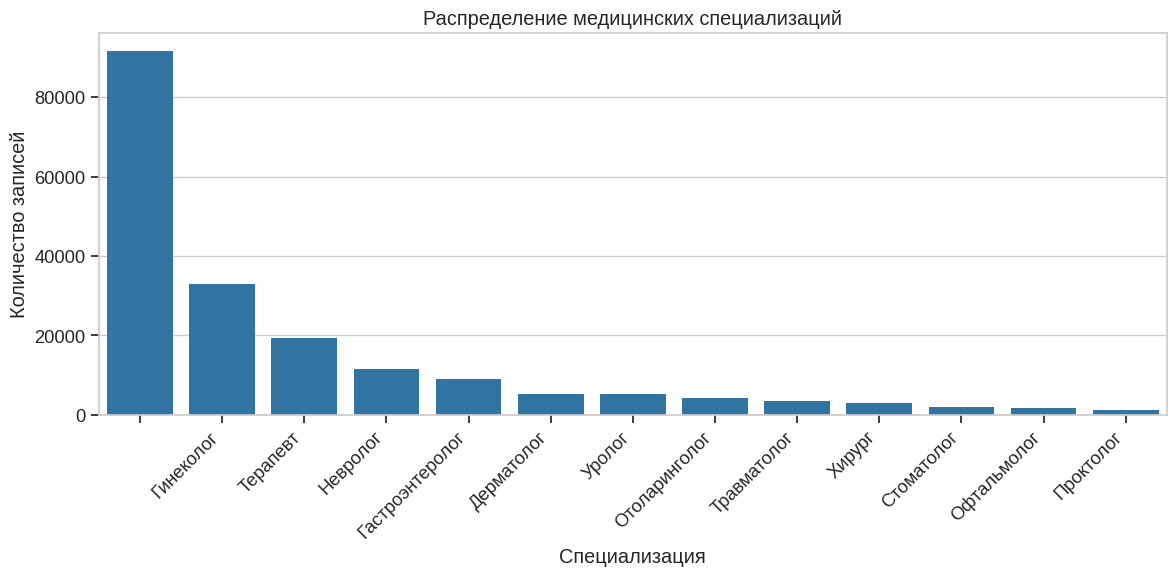

,count
spec10,
,91669
Гинеколог,32985
Терапевт,19303
Невролог,11421
Гастроэнтеролог,8913
Дерматолог,5320
Уролог,5145
Отоларинголог,4180
Травматолог,3419


,desc,spec10
795,Моему сыну 2.3 года он постоянно дерётся и не ...,
155677,Нужно сделать мрт коленного сустава. Ранее был...,
70170,"Здравствуйте. Подскажите, пожалуйста, на какой...",Гинеколог


In [3]:
# Загружаем датасет
dataset = load_dataset(
    "blinoff/medical_qa_ru_data",
    trust_remote_code=True
)

# Основные данные находятся в train split
df = dataset["train"].to_pandas()

# Размер и названия колонок
print(f"Размер датасета: {df.shape}")
print(f"Количество записей: {len(df):,}")
print(f"Колонки: {df.columns.tolist()}")

# Распределение классов
class_counts = df["spec10"].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Распределение медицинских специализаций")
plt.xlabel("Специализация")
plt.ylabel("Количество записей")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Численное распределение классов
display(class_counts.to_frame("count"))

# Три случайных примера
display(
    df[["desc", "spec10"]]
    .sample(3, random_state=SEED)
)

## Задание 2. Очистка данных (5 баллов)

Сырые данные из интернета всегда содержат много мусора. Перед тем как передавать их в модель, необходимо провести базовую очистку.

**Что нужно сделать:**
1. Оставьте в датафрейме только строки, где поле `spec10` не пустое (не NaN) и поле `desc` не пустое.
2. Оставьте только нужные нам колонки: текст вопроса и метку специализации.
3. Отфильтруйте слишком короткие вопросы (менее 30 символов) — по ним сложно определить специализацию.
4. Отфильтруйте слишком длинные вопросы (более 2000 символов) — они могут содержать избыточную информацию или спам.
5. Выведите размер датасета после очистки. Насколько он уменьшился?


In [4]:
# Размер исходного датасета
size_before = len(df)

# Удаляем строки с пустыми значениями desc и spec10
df_clean = df.dropna(subset=["desc", "spec10"]).copy()
df_clean["desc"] = df_clean["desc"].astype(str).str.strip()
df_clean["spec10"] = df_clean["spec10"].astype(str).str.strip()
df_clean = df_clean[
    (df_clean["desc"] != "") &
    (df_clean["spec10"] != "")
].copy()

# Оставляем только нужные колонки
df_clean = df_clean[["desc", "spec10"]]

# Фильтруем тексты по длине
text_length = df_clean["desc"].str.len()
df_clean = df_clean[
    (text_length >= 30) &
    (text_length <= 2000)
].reset_index(drop=True)

# Насколько уменьшился датасет
size_after = len(df_clean)
removed = size_before - size_after
removed_pct = removed / size_before * 100

print(f"Размер до очистки:     {size_before:,}")
print(f"Размер после очистки:  {size_after:,}")
print(f"Удалено записей:       {removed:,}")
print(f"Датасет уменьшился на: {removed_pct:.2f}%")


Размер до очистки:     190,335
Размер после очистки:  89,319
Удалено записей:       101,016
Датасет уменьшился на: 53.07%


## Задание 3. Дедупликация тремя способами (12 баллов)

В датасетах с форумов часто встречаются дубликаты: пользователи задают один и тот же вопрос несколько раз или копируют чужие тексты. Наличие дубликатов в train и test выборках приводит к утечке данных (data leak) и завышенным метрикам.

Вам нужно реализовать дедупликацию тремя разными методами. Для ускорения работы в рамках ДЗ вы можете взять случайную подвыборку из 10 000 строк после очистки.

**Что нужно сделать:**
1. **Точное совпадение (хеш):** Найдите и удалите полные дубликаты текстов.
2. **Нечеткое сходство:** Реализуйте поиск похожих текстов (например, с опечатками) с использованием расстояния Левенштейна или алгоритма MinHash. Удалите найденные дубликаты.
3. **Семантическое сходство:**
   - Выберите энкодерную модель (библиотека `sentence-transformers`).
   - Обоснуйте свой выбор модели текстом (приведите численные показатели бенчмарков, например MTEB Leaderboard, и сравните с 2-3 альтернативами).
   - Создайте эмбеддинги для текстов.
   - Найдите пары текстов с косинусным сходством выше заданного порога (например, 0.95).
   - Обоснуйте выбранный порог.

*Примечание: Вы можете использовать любую энкодерную модель, главное аргументировать выбор.*


**Обоснование выбора энкодерной модели:**

Для семантической дедупликации выбрана модель `deepvk/USER-bge-m3`. Она специально адаптирована для русского языка и подходит для получения sentence embeddings.

Для этой задачи особенно важен показатель STS (Semantic Textual Similarity), так как мы сравниваем смысловую близость двух текстов. В опубликованном сравнении MTEB-rus модель `USER-bge-m3` показывает STS **76.76**. Для сравнения: `multilingual-e5-large-instruct` — **76.48**, `jina-embeddings-v3` — **76.04**, `ru-en-RoSBERTa` — **74.13**. При этом средний результат по задачам MTEB-rus у `USER-bge-m3` составляет **62.80**. Поэтому для русскоязычных медицинских текстов и задачи поиска семантически близких формулировок эта модель является подходящим выбором.

Источник сравнения: https://huggingface.co/deepvk/USER2-small

**Обоснование порога косинусного сходства:**

Используется порог **0.95**. Это достаточно консервативное значение: медицинские жалобы одной специализации часто содержат похожие слова, поэтому более низкий порог может ошибочно удалить разные вопросы на одну тему. Порог 0.95 оставляет только очень близкие по смыслу тексты и соответствует рекомендуемому ориентиру из условия задания.


In [5]:
import re
import hashlib
import unicodedata
from tqdm.auto import tqdm
from datasketch import MinHash, MinHashLSH
from sentence_transformers import SentenceTransformer, util

# Берем 20 000 случайных записей после очистки
df_dedup = df_clean.sample(n=20_000, random_state=SEED).reset_index(drop=True)
print(f"Исходная подвыборка: {len(df_dedup):,}")

# 1. Точные дубликаты по SHA-256 хешу текста
df_dedup["text_hash"] = df_dedup["desc"].apply(
    lambda text: hashlib.sha256(text.encode("utf-8")).hexdigest()
)

before = len(df_dedup)
df_dedup = df_dedup.drop_duplicates("text_hash").drop(columns="text_hash")
df_dedup = df_dedup.reset_index(drop=True)
exact_removed = before - len(df_dedup)
print(f"После exact dedup:    {len(df_dedup):,} (удалено {exact_removed:,})")

# 2. Нечеткие дубликаты: MinHash + LSH по символьным 5-граммам
MINHASH_THRESHOLD = 0.90
NUM_PERM = 128

def get_shingles(text, n=5):
    text = unicodedata.normalize("NFKC", text.lower())
    text = re.sub(r"\s+", " ", text).strip()
    if len(text) < n:
        return {text}
    return {text[i:i+n] for i in range(len(text) - n + 1)}

def get_minhash(text):
    minhash = MinHash(num_perm=NUM_PERM)
    for shingle in get_shingles(text):
        minhash.update(shingle.encode("utf-8"))
    return minhash

lsh = MinHashLSH(threshold=MINHASH_THRESHOLD, num_perm=NUM_PERM)
fuzzy_duplicates = []

for idx, text in enumerate(tqdm(df_dedup["desc"], desc="MinHash", total=len(df_dedup))):
    minhash = get_minhash(text)
    if lsh.query(minhash):
        fuzzy_duplicates.append(idx)
    else:
        lsh.insert(str(idx), minhash)

before = len(df_dedup)
df_dedup = df_dedup.drop(index=fuzzy_duplicates).reset_index(drop=True)
fuzzy_removed = before - len(df_dedup)
print(f"После fuzzy dedup:    {len(df_dedup):,} (удалено {fuzzy_removed:,})")

# 3. Семантические дубликаты по косинусному сходству эмбеддингов
ENCODER_MODEL = "deepvk/USER-bge-m3"
SEMANTIC_THRESHOLD = 0.95

print(f"Embedding model: {ENCODER_MODEL}")
print(f"Устройство модели: {DEVICE}")
encoder = SentenceTransformer(ENCODER_MODEL, device=DEVICE)
embeddings = encoder.encode(
    df_dedup["desc"].tolist(),
    batch_size=EMBED_BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_tensor=True,
)

clusters = util.community_detection(
    embeddings,
    threshold=SEMANTIC_THRESHOLD,
    min_community_size=2,
)

semantic_duplicates = set()
for cluster in clusters:
    semantic_duplicates.update(cluster[1:])

before = len(df_dedup)
df_dedup = df_dedup.drop(index=list(semantic_duplicates)).reset_index(drop=True)
semantic_removed = before - len(df_dedup)
print(f"После semantic dedup: {len(df_dedup):,} (удалено {semantic_removed:,})")


Исходная подвыборка: 20,000
После exact dedup:    19,959 (удалено 41)


MinHash:   0%|          | 0/19959 [00:00<?, ?it/s]

После fuzzy dedup:    19,943 (удалено 16)
Embedding model: deepvk/USER-bge-m3
Устройство модели: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/3.33M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/963 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Batches:   0%|          | 0/312 [00:00<?, ?it/s]

После semantic dedup: 19,903 (удалено 40)


## Задание 4. Форматирование в SFT формат (5 баллов)

Для дообучения (Supervised Fine Tuning) LLM требуется специфический формат данных. Обычно это диалоговый формат (ChatML, Alpaca и др.), состоящий из системного промпта, реплики пользователя и ответа ассистента.

**Что нужно сделать:**
1. Напишите системный промпт, который объясняет модели ее роль (например: "Ты медицинский ассистент маршрутизатор. Твоя задача...").
2. Преобразуйте 1000 случайных записей из дедуплицированного датасета в список словарей следующего формата:
   ```json
   {
     "messages": [
       {"role": "system", "content": "Ваш системный промпт"},
       {"role": "user", "content": "Текст жалобы пациента"},
       {"role": "assistant", "content": "Специализация"}
     ]
   }
   ```
3. Сохраните полученный список в файл `sft_dataset.jsonl`.
4. Выведите первые 2 примера на экран.


In [6]:
# Системный промпт для SFT
SYSTEM_PROMPT = (
    "Ты медицинский ассистент-маршрутизатор. "
    "По тексту жалобы пациента определи наиболее подходящую медицинскую специализацию. "
    "В ответе укажи только название специализации."
)

# Берем 1000 случайных записей из дедуплицированного датасета
sft_sample = df_dedup.sample(
    n=min(1000, len(df_dedup)),
    random_state=SEED
).reset_index(drop=True)

sft_data = []

for row in sft_sample.itertuples(index=False):
    sft_data.append({
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": row.desc},
            {"role": "assistant", "content": row.spec10},
        ]
    })

# Сохраняем в JSONL: один JSON-объект на строку
SFT_PATH = "sft_dataset.jsonl"

with open(SFT_PATH, "w", encoding="utf-8") as f:
    for item in sft_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"Сохранено записей: {len(sft_data):,}")
print(f"Файл: {SFT_PATH}")

# Первые два примера
for i, item in enumerate(sft_data[:2], start=1):
    print(f"\nПример {i}:")
    print(json.dumps(item, ensure_ascii=False, indent=2))


Сохранено записей: 1,000
Файл: sft_dataset.jsonl

Пример 1:
{
  "messages": [
    {
      "role": "system",
      "content": "Ты медицинский ассистент-маршрутизатор. По тексту жалобы пациента определи наиболее подходящую медицинскую специализацию. В ответе укажи только название специализации."
    },
    {
      "role": "user",
      "content": "Здравствуйте, завтра должны начаться месячные. Но я не чувствую вообще ничего. После полового акта на 6 день начала сильно болеть грудь (касаться даже не могла) через 2 дня начал болеть низ живота сильно. На 12 день после полового акта все закончилось и больше не болит. Сейчас грудь практически не беспокоит. немного чувствую дискомфорт и все. Живот иногда покалывает (как будто иглой тыкают - секунду и все). Может ли это говорить о возможной беременности? ХГЧ завтра пойду сдавать только, к гинекологу 15 мая. Может ли боль в матке говорить о развитии спаек? Делала УЗИ малого таза 4,5 месяцев назад - было все хорошо. Половой акт был на 13 день, ци

## Задание 5. Разметка через LLM (zero-shot) (8 баллов)

Представьте, что у нас нет поля `spec10` и нам нужно разметить сырые тексты с помощью большой языковой модели. Мы будем использовать подход zero-shot (без примеров в промпте).

Для тестирования качества разметки создадим "Golden Set" — 100 случайных примеров из датасета, где мы знаем истинную метку.

**Что нужно сделать:**
1. Выделите 100 примеров в `golden_set`.
2. Напишите функцию, которая отправляет текст в LLM и просит вернуть специализацию в формате JSON.
3. Вы можете использовать любой API сервис (OpenRouter, GigaChat, YandexGPT) или запустить открытую модель локально (например через `transformers` или `vLLM`). Главное — аргументируйте выбор модели.
4. Разметьте все 100 примеров из `golden_set`.
5. Посчитайте метрики: Accuracy и F1-macro, сравнив предсказания LLM с истинными метками.
6. Выведите матрицу ошибок (classification report).


**Обоснование выбора LLM для разметки:**

Для разметки выбрана `google/gemini-2.5-flash-lite` через OpenRouter. Модель рассчитана на массовую классификацию и извлечение данных, поддерживает structured output и хорошо подходит для русскоязычного текста. Она заметно дешевле обычной Gemini 2.5 Flash: на OpenRouter стоимость составляет примерно `$0.10` за 1 млн входных и `$0.40` за 1 млн выходных токенов. Для классификации reasoning отключаем и используем `temperature=0`, чтобы ответы были стабильнее и дешевле.

Источники: https://openrouter.ai/google/gemini-2.5-flash-lite


In [8]:
from openai import OpenAI
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter
from tqdm.auto import tqdm

LLM_MODEL = "google/gemini-2.5-flash-lite"
BATCH_SIZE = 10
MAX_WORKERS = 4

def get_openrouter_api_key():
    """Получает OpenRouter API key из окружения, Kaggle или Colab Secrets."""
    api_key = os.getenv("OPENROUTER_API_KEY")

    if not api_key and os.path.exists("/kaggle/working"):
        try:
            from kaggle_secrets import UserSecretsClient
            api_key = UserSecretsClient().get_secret("OPENROUTER_API_KEY")
        except Exception:
            pass

    if not api_key:
        try:
            from google.colab import userdata
            api_key = userdata.get("OPENROUTER_API_KEY")
        except Exception:
            pass

    if not api_key:
        raise ValueError(
            "Не найден OPENROUTER_API_KEY. Добавьте ключ в переменную окружения, "
            "Kaggle Secrets или Google Colab Secrets."
        )

    return api_key.strip()

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=get_openrouter_api_key(),
    timeout=60.0,
    max_retries=0,
)

print(f"LLM: {LLM_MODEL}")
print("LLM backend: OpenRouter API (удаленный сервер)")
print(f"Обычный batch size: {BATCH_SIZE}, параллельных запросов: {MAX_WORKERS}")

specializations = sorted(df_dedup["spec10"].unique().tolist())

def call_openrouter(messages, schema, temperature=0, max_tokens=1200):
    """Запрос к OpenRouter через OpenAI-compatible SDK."""
    response_format = {
        "type": "json_schema",
        "json_schema": {
            "name": "result",
            "strict": True,
            "schema": schema,
        },
    }

    last_error = None

    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=messages,
                temperature=temperature,
                max_tokens=max_tokens,
                response_format=response_format,
                extra_body={
                    "reasoning": {"effort": "none"},
                    "provider": {"require_parameters": True},
                },
            )

            content = response.choices[0].message.content
            return json.loads(content)

        except Exception as e:
            last_error = e
            if attempt < 2:
                time.sleep(2 ** attempt)

    raise RuntimeError(f"OpenRouter request failed after 3 attempts: {last_error}")

ZERO_SHOT_SYSTEM = (
    "Ты медицинский ассистент-маршрутизатор. "
    "Для каждой жалобы выбери ровно одну наиболее подходящую медицинскую специализацию. "
    "Ориентируйся на основную жалобу и профиль врача, к которому пациента логично направить. "
    "Не ставь диагноз, не объясняй решение и не добавляй текст вне результата. "
    "Обязательно сохрани id каждого входного текста. "
    f"Допустимые специализации: {', '.join(specializations)}."
)

def make_classification_schema(n_items):
    """Строгая схема: модель должна вернуть ровно один ответ на каждый текст."""
    return {
        "type": "object",
        "properties": {
            "results": {
                "type": "array",
                "minItems": n_items,
                "maxItems": n_items,
                "items": {
                    "type": "object",
                    "properties": {
                        "id": {"type": "integer"},
                        "specialization": {
                            "type": "string",
                            "enum": specializations,
                        },
                    },
                    "required": ["id", "specialization"],
                    "additionalProperties": False,
                },
            }
        },
        "required": ["results"],
        "additionalProperties": False,
    }

def classify_batch(batch, system_prompt=ZERO_SHOT_SYSTEM, temperature=0):
    items = [
        {"id": int(row.item_id), "text": row.desc}
        for row in batch.itertuples(index=False)
    ]

    messages = [
        {"role": "system", "content": system_prompt},
        {
            "role": "user",
            "content": (
                "Разметь все элементы массива. Верни ровно один результат для каждого id.\n\n"
                + json.dumps(items, ensure_ascii=False)
            ),
        },
    ]

    max_output_tokens = max(800, 30 * len(items))

    result = call_openrouter(
        messages,
        make_classification_schema(len(items)),
        temperature=temperature,
        max_tokens=max_output_tokens,
    )

    predictions = {
        item["id"]: item["specialization"]
        for item in result["results"]
    }

    if len(predictions) != len(items):
        raise RuntimeError(
            f"Ожидалось {len(items)} ответов, получено {len(predictions)}"
        )

    return predictions

def classify_batched(data, system_prompt=ZERO_SHOT_SYSTEM, temperature=0, desc="Разметка"):
    """Классифицирует тексты небольшими параллельными батчами."""
    work = data.reset_index(drop=True).copy()
    work["item_id"] = np.arange(len(work))
    batches = [work.iloc[i:i + BATCH_SIZE] for i in range(0, len(work), BATCH_SIZE)]
    predictions = {}

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [
            executor.submit(classify_batch, batch, system_prompt, temperature)
            for batch in batches
        ]

        for future in tqdm(as_completed(futures), total=len(futures), desc=desc):
            predictions.update(future.result())

    missing = [i for i in range(len(work)) if i not in predictions]
    if missing:
        raise RuntimeError(f"LLM не вернула результаты для {len(missing)} текстов")

    return [predictions[i] for i in range(len(work))]

# Golden Set: 100 случайных примеров с известной истинной меткой
golden_set = df_dedup.sample(n=100, random_state=SEED).reset_index(drop=True)
golden_set["prediction"] = classify_batched(golden_set, desc="Zero-shot")

zero_accuracy = accuracy_score(golden_set["spec10"], golden_set["prediction"])
zero_f1 = f1_score(golden_set["spec10"], golden_set["prediction"], average="macro")

print(f"Accuracy: {zero_accuracy:.4f}")
print(f"F1-macro: {zero_f1:.4f}")
print("\nClassification report:")
print(classification_report(golden_set["spec10"], golden_set["prediction"], zero_division=0))


LLM: google/gemini-2.5-flash-lite
LLM backend: OpenRouter API (удаленный сервер)
Обычный batch size: 10, параллельных запросов: 4


Zero-shot:   0%|          | 0/10 [00:00<?, ?it/s]

Accuracy: 0.7900
F1-macro: 0.7571

Classification report:
                 precision    recall  f1-score   support

Гастроэнтеролог       1.00      0.78      0.88         9
      Гинеколог       1.00      0.87      0.93        38
     Дерматолог       0.86      1.00      0.92         6
       Невролог       0.78      1.00      0.88         7
  Отоларинголог       0.80      0.80      0.80         5
    Офтальмолог       1.00      1.00      1.00         1
      Проктолог       0.50      1.00      0.67         1
     Стоматолог       0.50      1.00      0.67         1
       Терапевт       0.56      0.56      0.56        18
    Травматолог       0.60      0.75      0.67         4
         Уролог       0.67      0.80      0.73         5
         Хирург       0.40      0.40      0.40         5

       accuracy                           0.79       100
      macro avg       0.72      0.83      0.76       100
   weighted avg       0.81      0.79      0.79       100



**Вывод по zero-shot:** модель показала Accuracy **0.790** и Macro F1 **0.757**. Для классификации без примеров это хороший базовый результат. Лучше всего модель справилась с офтальмологией, гинекологией и дерматологией. Наиболее слабые результаты получились для хирургии и терапии, где жалобы чаще пересекаются по симптомам с другими специализациями.


## Задание 6. Эмбеддинги и визуализация t-SNE (7 баллов)

Визуализация помогает понять, насколько хорошо тексты разных классов разделимы в векторном пространстве. Если классы сильно перемешаны, модели будет сложно их классифицировать.

**Что нужно сделать:**
1. Возьмите ваш `golden_set` (или подвыборку из 500-1000 записей датасета).
2. Сгенерируйте эмбеддинги текстов с помощью выбранной ранее энкодерной модели.
3. Используйте алгоритм t-SNE из `sklearn.manifold` для понижения размерности эмбеддингов до 2D.
4. Постройте scatter-plot (диаграмму рассеяния), где каждая точка — это текст, а цвет точки соответствует классу специализации.
5. Добавьте легенду.
6. Напишите краткий вывод: какие классы хорошо отделяются друг от друга, а какие смешиваются?


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Эмбеддинги: deepvk/USER-bge-m3 на cuda
t-SNE: sklearn, вычисление на CPU


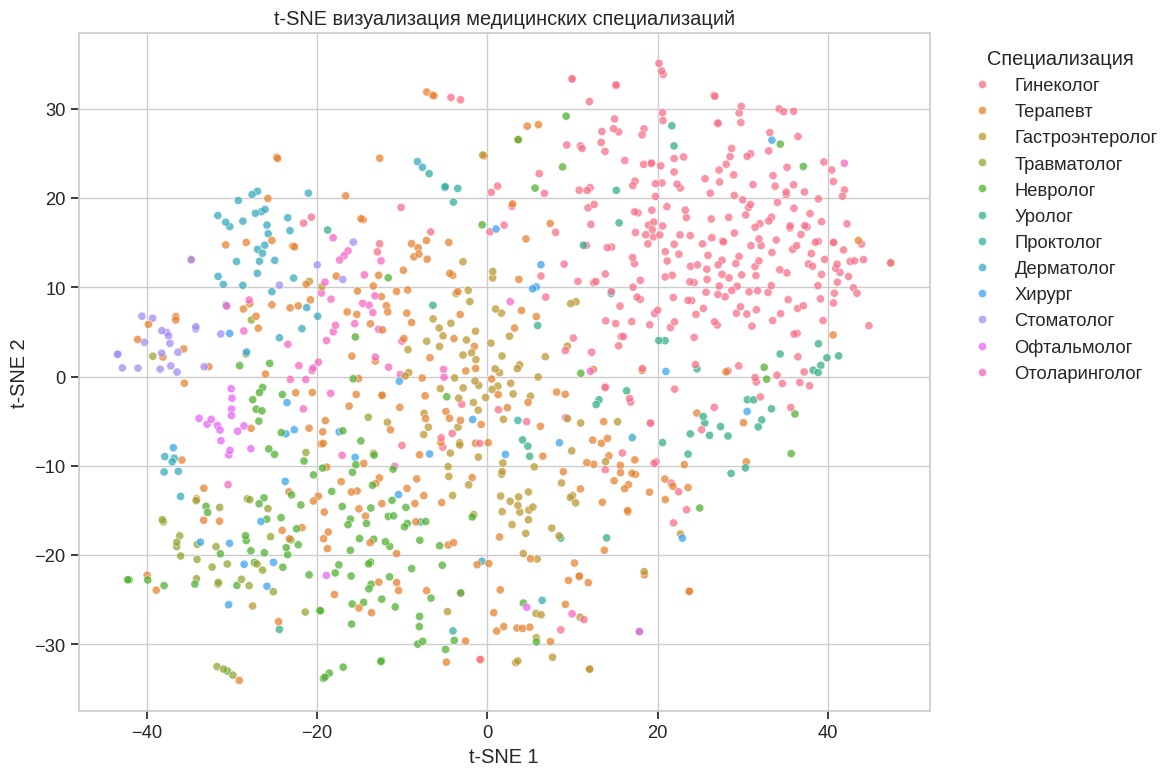

In [9]:
from sklearn.manifold import TSNE

# Для более наглядной визуализации берем 1000 записей
tsne_sample = df_dedup.sample(n=1000, random_state=SEED).reset_index(drop=True)

# Используем тот же энкодер, что и в задании 3
tsne_embeddings = encoder.encode(
    tsne_sample["desc"].tolist(),
    batch_size=EMBED_BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True,
)

print(f"Эмбеддинги: {ENCODER_MODEL} на {DEVICE}")
print("t-SNE: sklearn, вычисление на CPU")

# Понижаем размерность эмбеддингов до 2D
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=SEED,
)
points_2d = tsne.fit_transform(tsne_embeddings)

tsne_plot = pd.DataFrame({
    "x": points_2d[:, 0],
    "y": points_2d[:, 1],
    "spec10": tsne_sample["spec10"],
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=tsne_plot,
    x="x",
    y="y",
    hue="spec10",
    s=35,
    alpha=0.75,
)
plt.title("t-SNE визуализация медицинских специализаций")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Специализация", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Ваши выводы по графику:** на t-SNE лучше всего отделяется гинекология. Также заметны более компактные группы стоматологии, отоларингологии и дерматологии. При этом терапия, неврология, гастроэнтерология, урология и часть хирургических классов заметно пересекаются. Значит, для части специализаций тексты действительно семантически близки, и разделять их только по формулировке жалобы сложнее.


## Задание 7. Выводы по стандартной части (3 балла)

Напишите краткое резюме проделанной работы.

**Что нужно отразить:**
1. С какими основными проблемами в данных вы столкнулись при очистке?
2. Какой метод дедупликации показался вам наиболее эффективным и почему?
3. Насколько хорошо LLM справилась с задачей разметки в zero-shot режиме? Ожидали ли вы результат лучше или хуже?



**Итоговые выводы:**

1. Главная проблема исходных данных — большое количество пустых значений `spec10`, а также слишком короткие и слишком длинные тексты. После очистки осталось **89 319 из 190 335 записей**, то есть датасет уменьшился на **53.07%**.

2. На подвыборке из 20 000 записей exact dedup удалил **41** запись, fuzzy dedup — **16**, semantic dedup — **40**. Exact и semantic методы дали сопоставимый результат, но semantic dedup полезен тем, что находит близкие по смыслу формулировки, которые не совпадают буквально.

3. В zero-shot режиме LLM получила **Accuracy 0.790** и **Macro F1 0.757**. Для разметки без примеров это достаточно хороший результат, однако качество заметно различается между классами. Сложнее всего модели разделять специализации с похожими симптомами и более общими жалобами.


# Часть 2. Продвинутая (50 баллов)

В этой части мы сфокусируемся на продвинутых техниках: генерации синтетических данных, улучшении промптов и гибридных схемах разметки. Все эти методы активно применяются в индустрии для создания качественных датасетов при ограниченном бюджете.

*Важно: Для заданий 8, 10 и 11 вам нужно сгенерировать в сумме не менее 1000 новых записей.*


## Задание 8. Синтетическая генерация (Self-Instruct) (10 баллов)

Часто реальных данных не хватает для покрытия всех возможных краевых случаев (edge cases). Метод Self-Instruct позволяет использовать сильную LLM для генерации новых примеров на основе небольшого количества seed-примеров.

**Что нужно сделать:**
1. Напишите промпт для LLM, который просит сгенерировать реалистичные жалобы пациентов для конкретной специализации. Промпт должен требовать разнообразия в стиле (короткие, длинные, с ошибками, сленг).
2. Сгенерируйте не менее **300 новых примеров** для разных специализаций (равномерно распределите по классам).
3. Сохраните результаты.
4. Возьмите небольшую выборку синтетических данных и прогоните через вашу zero-shot классификацию из Задания 5. Сравните качество классификации на реальных и синтетических данных.


In [10]:
SYNTHETIC_TOTAL = 3000
GEN_BATCH_SIZE = 15


def make_synthetic_schema(n):
    return {
        "type": "object",
        "properties": {
            "texts": {
                "type": "array",
                "items": {
                    "type": "string",
                },
                "minItems": n,
                "maxItems": n,
            }
        },
        "required": ["texts"],
        "additionalProperties": False,
    }


def generate_for_class(label, n):
    prompt = f"""
Сгенерируй ровно {n} реалистичных русскоязычных жалоб пациентов
для медицинской специализации «{label}».

Требования:
- каждая жалоба должна соответствовать этой специализации;
- используй разные симптомы и жизненные ситуации;
- формулировки должны отличаться по длине и стилю;
- часть текстов может содержать опечатки, разговорные выражения и медицинский сленг;
- не упоминай название специализации;
- не добавляй нумерацию и пояснения;
- каждый элемент массива — отдельная жалоба пациента.
""".strip()

    messages = [
        {
            "role": "system",
            "content": (
                "Ты создаешь качественные синтетические данные "
                "для обучения медицинского маршрутизатора."
            ),
        },
        {
            "role": "user",
            "content": prompt,
        },
    ]

    schema = make_synthetic_schema(n)

    for attempt in range(5):
        try:
            result = call_openrouter(
                messages,
                schema,
                temperature=0.9,
                max_tokens=2500,
            )

            texts = [
                text.strip()
                for text in result["texts"]
                if isinstance(text, str) and text.strip()
            ]

            if len(texts) == n:
                return label, texts

        except (json.JSONDecodeError, KeyError, TypeError):
            pass

        time.sleep(2 ** attempt)

    raise RuntimeError(
        f"Не удалось сгенерировать батч: {label}, n={n}"
    )


# Равномерно распределяем 3000 примеров по классам
base = SYNTHETIC_TOTAL // len(specializations)
remainder = SYNTHETIC_TOTAL % len(specializations)

targets = {
    label: base + (1 if i < remainder else 0)
    for i, label in enumerate(specializations)
}


# Разбиваем генерацию каждого класса на небольшие батчи
generation_tasks = []

for label, total_n in targets.items():
    remaining = total_n

    while remaining > 0:
        batch_n = min(GEN_BATCH_SIZE, remaining)
        generation_tasks.append((label, batch_n))
        remaining -= batch_n


synthetic_rows = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [
        executor.submit(generate_for_class, label, n)
        for label, n in generation_tasks
    ]

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Self-Instruct",
    ):
        label, texts = future.result()

        synthetic_rows.extend(
            {
                "text": text,
                "true_label": label,
            }
            for text in texts
        )


synthetic_df = (
    pd.DataFrame(synthetic_rows)
    .drop_duplicates("text")
    .reset_index(drop=True)
)

print(f"Получено всего: {len(synthetic_rows):,}")
print(f"После удаления полных дублей: {len(synthetic_df):,}")

display(
    synthetic_df["true_label"]
    .value_counts()
    .sort_index()
)


synthetic_df.to_json(
    "synthetic_self_instruct.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)


# Проверяем качество наслучайных синтетических примерах
synthetic_eval = synthetic_df.sample(
    n=min(300, len(synthetic_df)),
    random_state=SEED,
).reset_index(drop=True)

synthetic_eval_for_model = synthetic_eval.rename(
    columns={"text": "desc"}
)

synthetic_eval["prediction"] = classify_batched(
    synthetic_eval_for_model,
    desc="Synthetic eval",
)

synthetic_accuracy = accuracy_score(
    synthetic_eval["true_label"],
    synthetic_eval["prediction"],
)

synthetic_f1 = f1_score(
    synthetic_eval["true_label"],
    synthetic_eval["prediction"],
    average="macro",
)

print(
    f"Real Golden Set   — Accuracy: {zero_accuracy:.3f}, "
    f"F1-macro: {zero_f1:.3f}"
)

print(
    f"Synthetic sample — Accuracy: {synthetic_accuracy:.3f}, "
    f"F1-macro: {synthetic_f1:.3f}"
)

Self-Instruct:   0%|          | 0/204 [00:00<?, ?it/s]

Получено всего: 3,000
После удаления полных дублей: 2,988


,count
true_label,
Гастроэнтеролог,250
Гинеколог,248
Дерматолог,250
Невролог,250
Отоларинголог,248
Офтальмолог,249
Проктолог,250
Стоматолог,249
Терапевт,249


Synthetic eval:   0%|          | 0/30 [00:00<?, ?it/s]

Real Golden Set   — Accuracy: 0.790, F1-macro: 0.757
Synthetic sample — Accuracy: 0.800, F1-macro: 0.800


**Вывод по Self-Instruct:** сгенерировано **3000** примеров, после удаления полных дублей осталось **2988 уникальных текстов**. Распределение по специализациям осталось практически равномерным — около 250 примеров на класс.

На выборке из 300 синтетических примеров zero-shot классификация показала Accuracy **0.800** и Macro F1 **0.800**, тогда как на реальном Golden Set результаты составили **0.790** и **0.757** соответственно. Синтетические примеры классифицируются немного легче, особенно с точки зрения Macro F1. Это может говорить о том, что генеративная модель создаёт более явно выраженные и менее неоднозначные признаки специализаций. Поэтому Self-Instruct полезен для расширения данных, но синтетические обращения лучше использовать вместе с реальными.


## Задание 9. Улучшение разметки (few-shot) (8 баллов)

Zero-shot разметка часто ошибается на сложных примерах. Добавление нескольких качественных примеров в промпт (few-shot) может значительно улучшить результат.

**Что нужно сделать:**
1. Разработайте few-shot промпт. Добавьте в него по 1-2 хороших примера жалоб для каждой специализации.
2. Прогоните ваш `golden_set` (из Задания 5) через новый few-shot промпт.
3. Посчитайте метрики (Accuracy, F1-macro) и сравните их с результатами zero-shot.
4. Проведите анализ ошибок: посмотрите на 3-5 примеров, где few-shot модель ошиблась. Как вы думаете, почему это произошло?


In [11]:
# Берем по одному типичному примеру на класс: текст с длиной, близкой к медианной
few_shot_pool = df_dedup[~df_dedup["desc"].isin(golden_set["desc"])].copy()
few_shot_pool["text_len"] = few_shot_pool["desc"].str.len()

few_shot_examples = []
for label, group in few_shot_pool.groupby("spec10"):
    median_len = group["text_len"].median()
    row = group.loc[(group["text_len"] - median_len).abs().idxmin()]
    few_shot_examples.append({
        "text": row["desc"],
        "specialization": label,
    })

FEW_SHOT_SYSTEM = (
    "Ты медицинский ассистент-маршрутизатор. "
    "Для каждой новой жалобы выбери ровно одну наиболее подходящую специализацию. "
    "Не ставь диагноз и не добавляй пояснений. Сохраняй id. "
    f"Допустимые специализации: {', '.join(specializations)}.\n\n"
    "Примеры правильной разметки:\n"
    + json.dumps(few_shot_examples, ensure_ascii=False)
)

few_shot_predictions = classify_batched(
    golden_set[["desc", "spec10"]],
    system_prompt=FEW_SHOT_SYSTEM,
    temperature=0,
    desc="Few-shot",
)

golden_set["few_shot_prediction"] = few_shot_predictions
few_accuracy = accuracy_score(golden_set["spec10"], golden_set["few_shot_prediction"])
few_f1 = f1_score(golden_set["spec10"], golden_set["few_shot_prediction"], average="macro")

print(f"Zero-shot — Accuracy: {zero_accuracy:.4f}, F1-macro: {zero_f1:.4f}")
print(f"Few-shot  — Accuracy: {few_accuracy:.4f}, F1-macro: {few_f1:.4f}")

# Показываем до 5 ошибок для дальнейшего анализа
few_errors = golden_set[
    golden_set["spec10"] != golden_set["few_shot_prediction"]
][["desc", "spec10", "few_shot_prediction"]].head(5)

display(few_errors)


Few-shot:   0%|          | 0/10 [00:00<?, ?it/s]

Zero-shot — Accuracy: 0.7900, F1-macro: 0.7571
Few-shot  — Accuracy: 0.7800, F1-macro: 0.7811


,desc,spec10,few_shot_prediction
1,"Здравствуйте, уже как неделю у меня фобия глот...",Терапевт,Невролог
14,"Здравствуйте, присутствует запах ацетона во рт...",Уролог,Терапевт
16,"Три врача, два мрт, узи, рентген, процедуры, л...",Травматолог,Терапевт
20,Доброе утро уважаемые врачи. У меня такой вопр...,Терапевт,Невролог
21,Здравствуйте. Можете дать коментарии по анализу.,Гинеколог,Терапевт


**Анализ ошибок:** few-shot дал неоднозначный результат. Accuracy немного снизилась с **0.790 до 0.780**, однако Macro F1 выросла с **0.757 до 0.781**. Это означает, что общая доля правильных ответов почти не изменилась, но качество стало более равномерным между классами.

Ошибки в основном возникают на неоднозначных жалобах. Например, терапевтические случаи модель относит к неврологии, а отдельные урологические и гинекологические обращения — к терапии. Такие тексты содержат симптомы, которые могут относиться сразу к нескольким специализациям. Один few-shot пример на класс помогает обозначить характер класса, но недостаточен для полного описания границ между близкими специализациями.


## Задание 10. Оценка уверенности LLM (10 баллов)

При автоматической разметке важно понимать, когда модель не уверена в своем ответе. Такие примеры лучше отправить на ручную проверку асессорам (human-in-the-loop).

Уверенность можно оценить различными способами:
- Запросить у API `logprobs` (вероятности токенов) для токенов ответа для подсчета **перплексии ответа**. Важно, далеко не все API сервисы возвращают logprobs, изучайте их документацию.
- Использовать sampling (temperature > 0.7): сгенерировать ответ 5 раз для одного промпта. Если все 5 раз класс совпадает — уверенность высокая. Если ответы разные — низкая. В том числе возможно использование beam search.

**Что нужно сделать:**
1. Реализуйте один из методов оценки уверенности.
2. Сгенерируйте или разметьте не менее **300 новых примеров** с обязательной фиксацией показателя уверенности (confidence score).
3. Постройте гистограмму распределения уверенности модели.
4. Выведите 3 примера с самой низкой уверенностью. Действительно ли они сложные/неоднозначные?


Текстов: 3,000; батчей за прогон: 120; прогонов: 5; API-запросов: 600


Confidence 3000: прогон 1/5:   0%|          | 0/120 [00:00<?, ?it/s]

Confidence 3000: прогон 2/5:   0%|          | 0/120 [00:00<?, ?it/s]

Confidence 3000: прогон 3/5:   0%|          | 0/120 [00:00<?, ?it/s]

Confidence 3000: прогон 4/5:   0%|          | 0/120 [00:00<?, ?it/s]

Confidence 3000: прогон 5/5:   0%|          | 0/120 [00:00<?, ?it/s]

Обработано записей: 3,000

Распределение confidence:


,count
confidence,
0.4,5
0.6,89
0.8,148
1.0,2758


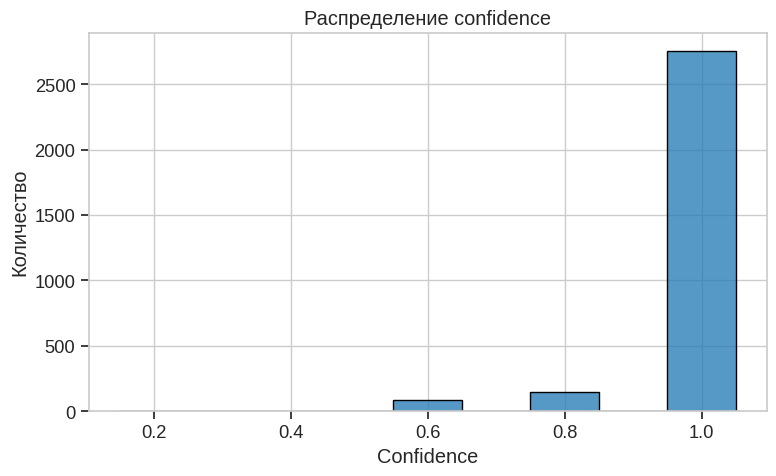

Три примера с самой низкой уверенностью:


,desc,spec10,llm_label,confidence
2538,"Ситуация такая, в 3 часа ночи женщина лет 40 н...",Гастроэнтеролог,Хирург,0.4
2553,здравствуйте! принимаю таблетки Силуэт по назн...,Гинеколог,Терапевт,0.4
1770,"Здравствуйте, а филлеры для носа чтоб убрать я...",Терапевт,Терапевт,0.4


In [12]:
CONFIDENCE_N = 3000
N_RUNS = 5
CONFIDENCE_BATCH_SIZE = 25

# Берем новые реальные тексты, не входящие в Golden Set
used_texts = set(golden_set["desc"])

confidence_pool = df_dedup[
    ~df_dedup["desc"].isin(used_texts)
].copy()

confidence_df = confidence_pool.sample(
    n=CONFIDENCE_N,
    random_state=SEED + 1,
).reset_index(drop=True)

def sampling_confidence(
    data,
    n_runs=5,
    batch_size=25,
    temperature=0.9,
    desc="Confidence",
):
    """Confidence = доля самого частого ответа среди нескольких прогонов."""
    work = data.reset_index(drop=True).copy()
    work["item_id"] = np.arange(len(work))

    batches = [
        work.iloc[i:i + batch_size]
        for i in range(0, len(work), batch_size)
    ]

    predictions = [[None] * len(work) for _ in range(n_runs)]

    print(
        f"Текстов: {len(work):,}; батчей за прогон: {len(batches)}; "
        f"прогонов: {n_runs}; API-запросов: {len(batches) * n_runs}"
    )

    # Прогоны идут последовательно, батчи внутри прогона — параллельно.
    for run_id in range(n_runs):
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = [
                executor.submit(
                    classify_batch,
                    batch,
                    ZERO_SHOT_SYSTEM,
                    temperature,
                )
                for batch in batches
            ]

            for future in tqdm(
                as_completed(futures),
                total=len(futures),
                desc=f"{desc}: прогон {run_id + 1}/{n_runs}",
            ):
                result = future.result()

                for item_id, label in result.items():
                    predictions[run_id][item_id] = label

    for run_id in range(n_runs):
        missing = sum(label is None for label in predictions[run_id])
        if missing:
            raise RuntimeError(
                f"В прогоне {run_id + 1} не получено ответов для {missing} текстов"
            )

    final_labels = []
    confidences = []

    for item_id in range(len(work)):
        labels = [predictions[run][item_id] for run in range(n_runs)]
        label, count = Counter(labels).most_common(1)[0]
        final_labels.append(label)
        confidences.append(count / n_runs)

    return final_labels, confidences

confidence_df["llm_label"], confidence_df["confidence"] = sampling_confidence(
    confidence_df,
    n_runs=N_RUNS,
    batch_size=CONFIDENCE_BATCH_SIZE,
    temperature=0.9,
    desc="Confidence 3000",
)

confidence_df.to_json(
    "confidence_3000.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

print(f"Обработано записей: {len(confidence_df):,}")
print("\nРаспределение confidence:")
display(
    confidence_df["confidence"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

plt.figure(figsize=(8, 5))
sns.histplot(
    confidence_df["confidence"],
    bins=np.arange(0.15, 1.11, 0.1),
)
plt.title("Распределение confidence")
plt.xlabel("Confidence")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

print("Три примера с самой низкой уверенностью:")
display(
    confidence_df
    .sort_values("confidence")
    [["desc", "spec10", "llm_label", "confidence"]]
    .head(3)
)


**Вывод по confidence:** модель показала высокую стабильность предсказаний: **2758 из 3000 примеров (91.9%)** получили confidence `1.0`, то есть класс совпал во всех пяти независимых прогонах. Только 242 примера имели confidence ниже 1.0.

Самые неуверенные примеры действительно неоднозначны. Например, жалоба с острыми симптомами может относиться как к гастроэнтерологии, так и к хирургии, а вопросы о лекарственных препаратах или косметологических процедурах не всегда однозначно соответствуют одной из доступных медицинских специализаций. Поэтому согласованность нескольких генераций можно использовать как простой практический сигнал для передачи сложных случаев человеку.


## Задание 11. Гибридная схема разметки (10 баллов)

В реальных проектах разметка LLM стоит денег, а ручная разметка — еще больше денег и времени. Оптимальный подход: LLM размечает простые примеры (где ее уверенность высока), а сложные отправляются людям.

**Что нужно сделать:**
1. Сгенерируйте/разметьте еще не менее **400 примеров** (чтобы в сумме за Часть 2 получилось >= 1000 записей).
2. Напишите функцию симуляции "шумного" ручного разметчика. Эта функция принимает истинную метку и с вероятностью 95% возвращает ее, а с вероятностью 5% совершает ошибку (возвращает случайный другой класс).
3. Постройте гибридный пайплайн:
   - Если уверенность LLM выше порога `T`, принимаем метку LLM.
   - Если ниже `T`, отправляем "человеку" (используем симуляцию из п.2).
4. Проведите эксперимент с разными значениями порога `T`. Постройте график: по оси X — порог `T`, по оси Y две линии — итоговая Accuracy датасета и доля примеров, отправленных человеку.
5. Выберите оптимальный порог и обоснуйте выбор.


Текстов: 4,000; батчей за прогон: 160; прогонов: 5; API-запросов: 800


Hybrid 4000: прогон 1/5:   0%|          | 0/160 [00:00<?, ?it/s]

Hybrid 4000: прогон 2/5:   0%|          | 0/160 [00:00<?, ?it/s]

Hybrid 4000: прогон 3/5:   0%|          | 0/160 [00:00<?, ?it/s]

Hybrid 4000: прогон 4/5:   0%|          | 0/160 [00:00<?, ?it/s]

Hybrid 4000: прогон 5/5:   0%|          | 0/160 [00:00<?, ?it/s]

,threshold,accuracy,human_share
0,0.0,0.76800,0.00000
1,0.1,0.76800,0.00000
2,0.2,0.76800,0.00000
3,0.3,0.76800,0.00000
4,0.4,0.77000,0.00325
5,0.5,0.77000,0.00325
6,0.6,0.78600,0.03225
7,0.7,0.78600,0.03225
8,0.8,0.80175,0.07100
9,0.9,0.80175,0.07100


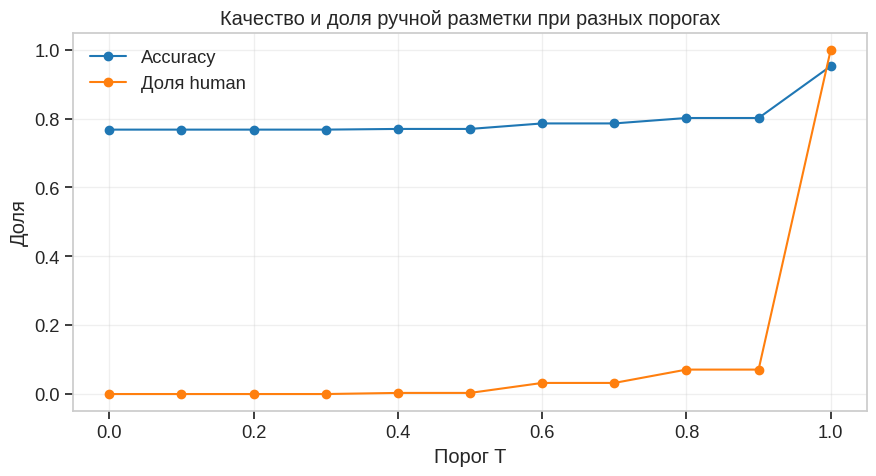

In [13]:
HYBRID_N = 4000

# Берем новые записи без пересечения
# с Golden Set и confidence-выборкой
used_texts = (
    set(golden_set["desc"])
    | set(confidence_df["desc"])
)

hybrid_pool = df_dedup[
    ~df_dedup["desc"].isin(used_texts)
].copy()

hybrid_df = hybrid_pool.sample(
    n=HYBRID_N,
    random_state=SEED + 2,
).reset_index(drop=True)


hybrid_df["llm_label"], hybrid_df["confidence"] = sampling_confidence(
    hybrid_df,
    n_runs=N_RUNS,
    batch_size=CONFIDENCE_BATCH_SIZE,
    desc="Hybrid 4000",
)


# Симуляция ручного разметчика:
# в 95% случаев он выбирает правильную метку
rng = random.Random(SEED)


def noisy_human(true_label):

    if rng.random() < 0.95:
        return true_label

    other_labels = [
        label
        for label in specializations
        if label != true_label
    ]

    return rng.choice(other_labels)


# Ответ человека фиксируем один раз,
# чтобы все пороги сравнивались на одинаковых данных
hybrid_df["human_label"] = hybrid_df["spec10"].apply(
    noisy_human
)


thresholds = np.arange(0.0, 1.01, 0.1)

rows = []

for threshold in thresholds:

    use_llm = hybrid_df["confidence"] > threshold

    final_labels = np.where(
        use_llm,
        hybrid_df["llm_label"],
        hybrid_df["human_label"],
    )

    rows.append({
        "threshold": round(float(threshold), 1),
        "accuracy": accuracy_score(
            hybrid_df["spec10"],
            final_labels,
        ),
        "human_share": float((~use_llm).mean()),
    })


threshold_results = pd.DataFrame(rows)

display(threshold_results)


plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["accuracy"],
    marker="o",
    label="Accuracy",
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["human_share"],
    marker="o",
    label="Доля human",
)

plt.xlabel("Порог T")
plt.ylabel("Доля")
plt.title("Качество и доля ручной разметки при разных порогах")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Рассматриваем только варианты,
# где человеку отправляется не более 20% примеров
practical_thresholds = threshold_results[
    threshold_results["human_share"] <= 0.20
].copy()

# Среди них выбираем вариант с максимальной Accuracy
best_row = practical_thresholds.sort_values(
    ["accuracy", "human_share"],
    ascending=[False, True],
).iloc[0]

best_threshold = float(best_row["threshold"])

use_llm = hybrid_df["confidence"] > best_threshold

hybrid_df["final_label"] = np.where(
    use_llm,
    hybrid_df["llm_label"],
    hybrid_df["human_label"],
)

print(f"Выбранный порог: T={best_threshold:.1f}")
print(f"Accuracy: {best_row['accuracy']:.3f}")
print(
    f"Доля примеров, отправленных человеку: "
    f"{best_row['human_share']:.1%}"
)

Выбранный порог: T=0.8
Accuracy: 0.802
Доля примеров, отправленных человеку: 7.1%


**Обоснование выбора порога:** максимальная Accuracy достигается при `T=1.0` и составляет **0.953**, однако в этом случае человеку отправляются все примеры, поэтому такая схема практически теряет смысл.

При `T=0.8` итоговая Accuracy составляет **0.802**, а ручной проверки требуют только **7.1%** примеров. Это даёт заметное улучшение относительно полностью автоматической LLM-разметки (**0.768**) при небольшой доле ручной работы. Поэтому `T=0.8` выбран как наиболее практичный компромисс между качеством и стоимостью разметки.


## Задание 12. Публикация датасета на HuggingFace (7 баллов)

Итоговый результат вашей работы — это готовый набор данных, который можно использовать для обучения моделей. Отличная практика — делиться своими датасетами с сообществом, снабжая их подробной документацией (Dataset Card).

**Что нужно сделать:**
1. Соберите все сгенерированные и размеченные вами данные из Части 2 (не менее 1000 записей) в единый датасет формата HuggingFace `datasets`.
2. Загрузите датасет на свой аккаунт HuggingFace Hub (сделайте его публичным).
3. Напишите подробную **Dataset Card** (файл `README.md` в репозитории датасета).
4. Вставьте ссылку на ваш датасет в ячейку ниже.

**Требования к Dataset Card:**
- Описание задачи (для чего нужен датасет).
- Описание процесса генерации (какие модели использовались, как собирался).
- Численные показатели (размер датасета, распределение классов).
- Минимум 1 визуализация (например, сохраненный график распределения классов или t-SNE, загруженный как картинка).
- Примеры данных.


Итоговый размер датасета: 9,988


,count
source,
hybrid,4000
confidence_sampling,3000
self_instruct,2988


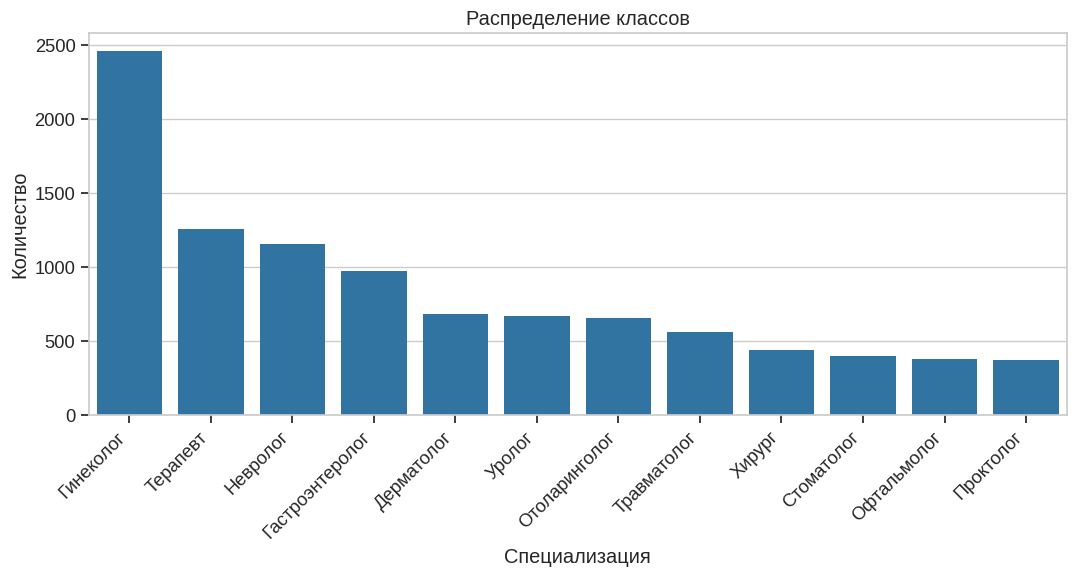

HuggingFace repo id (username/dataset-name): petaevd/russian-medical-routing-dataset


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nt/class_distribution.png: 100%|##########|  107kB /  107kB            

Датасет успешно опубликован:


[Открыть датасет на Hugging Face](https://huggingface.co/datasets/petaevd/russian-medical-routing-dataset)

In [16]:
from datasets import Dataset
from huggingface_hub import HfApi
from IPython.display import Markdown, display


def get_hf_write_token():
    """Читает HF_WRITE_TOKEN из окружения, Kaggle или Colab Secrets."""
    token = os.getenv("HF_WRITE_TOKEN")

    if not token and os.path.exists("/kaggle/working"):
        try:
            from kaggle_secrets import UserSecretsClient
            token = UserSecretsClient().get_secret("HF_WRITE_TOKEN")
        except Exception:
            pass

    if not token:
        try:
            from google.colab import userdata
            token = userdata.get("HF_WRITE_TOKEN")
        except Exception:
            pass

    if not token:
        raise ValueError(
            "Не найден HF_WRITE_TOKEN. "
            "Добавьте токен с правами Write в переменную окружения, "
            "Kaggle Secrets или Google Colab Secrets."
        )

    return token.strip()


# Объединяем результаты заданий 8, 10 и 11:
# 2988 Self-Instruct + 3000 confidence + 4000 hybrid
part_self = synthetic_df.copy()
part_self["label"] = part_self["true_label"]
part_self["reference_label"] = part_self["true_label"]
part_self["source"] = "self_instruct"
part_self["confidence"] = np.nan

part_self = part_self[
    ["text", "label", "reference_label", "source", "confidence"]
]


part_conf = confidence_df[
    ["desc", "spec10", "llm_label", "confidence"]
].copy()

part_conf.columns = [
    "text",
    "reference_label",
    "label",
    "confidence",
]

part_conf["source"] = "confidence_sampling"

part_conf = part_conf[
    ["text", "label", "reference_label", "source", "confidence"]
]


part_hybrid = hybrid_df[
    ["desc", "spec10", "final_label", "confidence"]
].copy()

part_hybrid.columns = [
    "text",
    "reference_label",
    "label",
    "confidence",
]

part_hybrid["source"] = "hybrid"

part_hybrid = part_hybrid[
    ["text", "label", "reference_label", "source", "confidence"]
]


# Итоговый датасет
final_df = pd.concat(
    [part_self, part_conf, part_hybrid],
    ignore_index=True,
)

print(f"Итоговый размер датасета: {len(final_df):,}")
display(final_df["source"].value_counts())


# Распределение классов
class_counts = (
    final_df["label"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
)

plt.title("Распределение классов")
plt.xlabel("Специализация")
plt.ylabel("Количество")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    "class_distribution.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# Данные Hugging Face
HF_REPO_ID = (
    os.getenv("HF_REPO_ID")
    or input("HuggingFace repo id (username/dataset-name): ").strip()
)

HF_WRITE_TOKEN = get_hf_write_token()


# Публикуем датасет
dataset_hf = Dataset.from_pandas(
    final_df,
    preserve_index=False,
)

dataset_hf.push_to_hub(
    HF_REPO_ID,
    token=HF_WRITE_TOKEN,
    private=False,
)


# Численное распределение классов для Dataset Card
distribution = "\n".join(
    f"- {label}: {count}"
    for label, count in class_counts.items()
)


# Несколько коротких примеров
example_rows = []

for row in final_df.head(3).itertuples(index=False):
    text = row.text.replace("\n", " ")[:180]

    example_rows.append(
        f"- **{row.label}** — {text}"
    )

examples = "\n".join(example_rows)


# Dataset Card
readme = f"""---
language:
- ru
task_categories:
- text-classification
size_categories:
- 1K<n<10K
---

# Russian Medical Routing Dataset

## Назначение

Датасет предназначен для классификации русскоязычных жалоб пациентов по медицинским специализациям.

## Состав

- Всего записей: **{len(final_df)}**
- Self-Instruct: **{len(part_self)}**
- Confidence sampling: **{len(part_conf)}**
- Hybrid: **{len(part_hybrid)}**

## Получение данных

- LLM: `{LLM_MODEL}` через OpenRouter.
- Self-Instruct: генерация новых жалоб по заданной специализации.
- Confidence sampling: 5 независимых классификаций; confidence определяется как доля наиболее частого ответа.
- Hybrid: при confidence > {best_threshold:.1f} используется ответ LLM, иначе симулированный ручной разметчик с точностью 95%.

## Распределение классов

{distribution}

![Распределение классов](class_distribution.png)

## Поля

- `text` — текст жалобы пациента
- `label` — итоговая метка
- `reference_label` — исходная или заданная метка
- `source` — способ получения записи
- `confidence` — confidence LLM, если применимо

## Примеры

{examples}

## Ограничения

Синтетические данные могут содержать повторяющиеся структуры и более типичные формулировки, чем реальные обращения. Датасет создан для учебных экспериментов и не предназначен для медицинской диагностики.
"""


with open(
    "README.md",
    "w",
    encoding="utf-8",
) as f:
    f.write(readme)


# Загружаем Dataset Card и график
api = HfApi(token=HF_WRITE_TOKEN)

api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=HF_REPO_ID,
    repo_type="dataset",
)

api.upload_file(
    path_or_fileobj="class_distribution.png",
    path_in_repo="class_distribution.png",
    repo_id=HF_REPO_ID,
    repo_type="dataset",
)


# Ссылка на опубликованный датасет
dataset_url = (
    f"https://huggingface.co/datasets/{HF_REPO_ID}"
)

print("Датасет успешно опубликован:")

display(
    Markdown(
        f"[Открыть датасет на Hugging Face]({dataset_url})"
    )
)

## Задание 13. Итоговые выводы (5 баллов)

Поздравляем, вы прошли полный цикл создания датасета для дообучения LLM! Напишите развернутые итоговые выводы по всей проделанной работе.

**Что нужно отразить:**
1. Сравните эффективность zero-shot, few-shot и гибридной стратегий разметки.
2. Дайте рекомендации: в каком случае (какой бюджет, какие требования к качеству) вы бы выбрали каждую из стратегий в реальном проекте?
3. Какие ограничения есть у метода генерации синтетических данных (Self-Instruct)? Заметили ли вы эффект однообразия в сгенерированных примерах?



**Итоговые выводы:**

**Zero-shot** показал Accuracy **0.790** и Macro F1 **0.757**. Это хороший базовый вариант для автоматической разметки: он не требует подготовки примеров и практически не требует ручной настройки.

**Few-shot** дал смешанный результат. Accuracy немного снизилась до **0.780**, но Macro F1 выросла до **0.781**. Значит, примеры помогли сделать качество более равномерным между классами, однако не увеличили общую долю правильных ответов. Few-shot имеет смысл использовать при наличии действительно качественных и репрезентативных демонстраций.

**Hybrid** оказался наиболее практичным вариантом при повышенных требованиях к качеству. При пороге `T=0.8` Accuracy составила **0.802**, а человеку потребовалось проверить только **7.1%** примеров. Для сравнения, использование человека для всех случаев (`T=1.0`) повышает Accuracy до **0.953**, но полностью устраняет экономический смысл автоматической разметки.

При ограниченном бюджете я бы использовал zero-shot. Few-shot подходит, если имеются качественные размеченные примеры для всех специализаций. Hybrid лучше использовать, когда ошибки стоят дороже и допустима небольшая доля ручной проверки.

Self-Instruct позволил получить **2988 уникальных синтетических примеров** из 3000 сгенерированных. На синтетической выборке модель показала Accuracy и Macro F1 **0.800**, что немного выше результатов на реальных данных. Это указывает на то, что синтетические обращения могут быть более типичными и менее неоднозначными. Кроме того, несмотря на высокую уникальность строк, генеративная модель может повторять похожие структуры, симптомы и стиль. Поэтому синтетические данные полезны для расширения обучающей выборки, но не должны полностью заменять реальные обращения.
